## Best Model — Multi-Task PCL Detection

This notebook contains the final, clean training pipeline for the best model found via Optuna hyperparameter search in `span_model.ipynb`.

**Architecture:** ALBERT-large-v2 encoder with two heads (multi-task):
1. **Category head:** [CLS] → 7 PCL category logits (auxiliary signal)
2. **Binary head:** concat([CLS], category_logits) → binary PCL prediction

**Key techniques:**
- Focal cross-entropy loss for class imbalance
- BCE auxiliary loss on PCL categories
- WeightedRandomSampler for 50/50 class balance per epoch
- Threshold optimization on validation set
- Model & trainer imported from `pcl_tf.span_tf`

In [4]:
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoTokenizer,
    TrainingArguments,
)
from pcl_tf.span_tf import SpanModel, MultiTaskTrainer

# CUDA optimizations
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

### Configuration
Load best hyperparameters from Optuna search and set model constants.

In [5]:
# --- BEST HYPERPARAMS (from Optuna search) ---
with open("best_hyperparams.json") as f:
    bp = json.load(f)

print("Best hyperparameters:")
print(json.dumps(bp, indent=2))

# --- CONFIGURATION ---
MODEL_CHECKPOINT = "albert/albert-large-v2"
CACHE_DIR = "./models_cache"
MAX_LENGTH = 256           
NUM_CATEGORIES = 7
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHT_DECAY = bp["weight_decay"]
WARMUP_RATIO = bp["warmup_ratio"] 
BATCH_SIZE = 8

LR = bp["lr"]             
DROPOUT = bp["dropout"]        
# Optuna's alpha/gamma were co-optimized WITH class_weights (5.27x).
# With per-class focal alpha alone (no CE weights), we need:
#   alpha ~ 0.75-0.85 for 9.5:1 imbalance (positive class weight)
#   gamma ~ 2.0-3.0   to compensate for removed class weights
FOCAL_ALPHA = 0.80   # weight for positive class; negatives get 0.20
FOCAL_GAMMA = 2.5    # stronger down-weighting of easy negatives
AUX_LOSS_WEIGHT = bp["aux_weight"]
GRAD_ACCUMULATION = 4
NUM_EPOCHS = 12           


print(f"\nUsing device: {DEVICE}")
print(f"Effective batch size: {BATCH_SIZE} × {GRAD_ACCUMULATION} = {BATCH_SIZE * GRAD_ACCUMULATION}")

Best hyperparameters:
{
  "best_f1": 0.5508982035928144,
  "lr": 4.220013592611256e-05,
  "focal_alpha": 0.7564673969807376,
  "focal_gamma": 1.7559525538896228,
  "aux_weight": 0.05416432353969669,
  "dropout": 0.2555105754207849,
  "weight_decay": 0.08876598072536068,
  "warmup_ratio": 0.17865423948100767
}

Using device: cuda
Effective batch size: 8 × 4 = 32


### Data Loading
Load binary labels and span-level category annotations, then merge into a single DataFrame with multi-label vectors.

In [6]:
# 1. Binary + text data (all samples — will be filtered below)
df = pd.read_csv("data/dontpatronizeme_pcl_cleaned.csv")
df = df.dropna(subset=["text", "par_id"])
df["par_id"] = df["par_id"].astype(int)

# 2. Span-level category annotations → per-paragraph multi-label vectors
cats_df = pd.read_csv(
    "data/dontpatronizeme_categories.tsv",
    sep="\t", header=None, skiprows=4, engine="python",
    names=["par_id", "art_id", "text", "keyword", "country_code",
           "span_start", "span_finish", "span_text", "pcl_category",
           "num_annotators"],
)
cats_df["par_id"] = cats_df["par_id"].astype(int)

# Build a 7-dim one-hot vector per par_id from the pcl_category column
CATEGORIES = sorted(cats_df["pcl_category"].unique())
print(f"PCL categories ({len(CATEGORIES)}): {CATEGORIES}")

cat_dummies = pd.get_dummies(cats_df[["par_id", "pcl_category"]], columns=["pcl_category"], prefix="", prefix_sep="")
cat_vectors = cat_dummies.groupby("par_id")[CATEGORIES].max().astype(int)
cat_vectors = cat_vectors.reset_index()
cat_vectors["multi_label"] = cat_vectors[CATEGORIES].values.tolist()

# 3. Merge: text + binary label + multi-label vector
merged = pd.merge(df, cat_vectors[["par_id", "multi_label"]], on="par_id", how="left")

# Rows without a category entry are non-PCL (all zeros)
merged["multi_label"] = merged["multi_label"].apply(lambda x: x if isinstance(x, list) else [0] * len(CATEGORIES))
merged["pcl_binary"] = merged["pcl_binary"].astype(int)

# --- CRITICAL: Filter to ONLY official train split par_ids ---
# pcl_cleaned.csv contains ALL data (train + dev). We must exclude dev par_ids
# to prevent data leakage into training.
train_semeval = pd.read_csv("data/train_semeval_parids-labels.csv")
train_par_ids = set(train_semeval["par_id"].astype(int))

dev_semeval = pd.read_csv("data/dev_semeval_parids-labels.csv")
dev_par_ids = set(dev_semeval["par_id"].astype(int))

before = len(merged)
merged = merged[merged["par_id"].isin(train_par_ids)].reset_index(drop=True)
removed = before - len(merged)

print(f"\nData leakage prevention:")
print(f"  Total in pcl_cleaned: {before}")
print(f"  Official train par_ids: {len(train_par_ids)}")
print(f"  Official dev par_ids (excluded): {len(dev_par_ids)}")
print(f"  Removed {removed} dev samples from training pool")
print(f"\nFiltered training dataset: {len(merged)}")
print(f"  PCL positive: {merged['pcl_binary'].sum()}  |  negative: {(merged['pcl_binary'] == 0).sum()}")

PCL categories (7): ['Authority_voice', 'Compassion', 'Metaphors', 'Presupposition', 'Shallow_solution', 'The_poorer_the_merrier', 'Unbalanced_power_relations']

Data leakage prevention:
  Total in pcl_cleaned: 10468
  Official train par_ids: 8375
  Official dev par_ids (excluded): 2094
  Removed 2093 dev samples from training pool

Filtered training dataset: 8375
  PCL positive: 794  |  negative: 7581


### Dataset & Tokenizer
Pre-tokenize all texts and build train/val datasets with weighted sampling for class balance.

In [7]:
# --- DATASET ---
from pcl_tf.dataset_manager import SpanDS

# --- TOKENIZER & SPLITS ---

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, cache_dir=CACHE_DIR)

train_idx, val_idx = train_test_split(
    range(len(merged)), test_size=0.1, random_state=42, stratify=merged["pcl_binary"]
)

texts = merged["text"].tolist()
binary = merged["pcl_binary"].tolist()
cats = merged["multi_label"].tolist()

def _select(idxs):
    return [texts[i] for i in idxs], [binary[i] for i in idxs], [cats[i] for i in idxs]

tr_texts, tr_bin, tr_cat = _select(train_idx)
va_texts, va_bin, va_cat = _select(val_idx)

print(f"Pre-tokenizing {len(tr_texts)} train + {len(va_texts)} val texts...")
train_ds = SpanDS(tr_texts, tr_bin, tr_cat, tokenizer, MAX_LENGTH)
val_ds = SpanDS(va_texts, va_bin, va_cat, tokenizer, MAX_LENGTH)

# --- Weighted sampler for class imbalance ---
class_counts = np.bincount(tr_bin)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in tr_bin]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

lengths = [len(ids) for ids in train_ds.input_ids]
print(f"\nToken length stats: mean={np.mean(lengths):.0f}, median={np.median(lengths):.0f}, "
      f"max={max(lengths)}, p95={np.percentile(lengths, 95):.0f}")
print(f"Train/val: {len(train_ds)}/{len(val_ds)}")
print(f"Class balance — neg: {class_counts[0]}, pos: {class_counts[1]}, "
      f"ratio: {class_counts[0]/class_counts[1]:.1f}:1")
print(f"WeightedRandomSampler active — effective 50/50 class balance per epoch.")

Pre-tokenizing 7537 train + 838 val texts...

Token length stats: mean=62, median=55, max=209, p95=130
Train/val: 7537/838
Class balance — neg: 6822, pos: 715, ratio: 9.5:1
WeightedRandomSampler active — effective 50/50 class balance per epoch.


### Metrics

In [8]:
def compute_metrics_binary(pred):
    """Binary F1 for the positive (PCL) class."""
    preds = pred.predictions.argmax(-1)
    labels = pred.label_ids
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    return {"f1": f1, "precision": p, "recall": r, "accuracy": accuracy_score(labels, preds)}

### Training
Build the SpanModel with best hyperparameters and train with the MultiTaskTrainer from `pcl_tf.span_tf`.

In [9]:
# --- BUILD MODEL ---
from pcl_tf.dataset_manager import SpanTaskCollator
from transformers import TrainerCallback

class ConditionalEarlyStoppingCallback(TrainerCallback):
    """Early stopping that only enforces patience after F1 exceeds a minimum threshold."""
    def __init__(self, patience: int = 3, min_f1: float = 0.5):
        self.patience = patience
        self.min_f1 = min_f1
        self.best_f1 = 0.0
        self.wait = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        current_f1 = metrics.get("eval_f1", 0.0)
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            self.wait = 0
        else:
            if self.best_f1 >= self.min_f1:
                self.wait += 1
                if self.wait >= self.patience:
                    print(f"\n⏹ Early stopping: F1 did not improve for {self.patience} evals "
                          f"(best={self.best_f1:.4f}, current={current_f1:.4f})")
                    control.should_training_stop = True
            # else: below threshold, keep training regardless

model = SpanModel(
    checkpoint=MODEL_CHECKPOINT,
    num_categories=NUM_CATEGORIES,
    dropout=DROPOUT,
    cache_dir=CACHE_DIR,
).to(DEVICE)

model = torch.compile(model, dynamic=True)

collator = SpanTaskCollator(tokenizer, padding="longest")

print(f"Class ratio: neg={class_counts[0]}, pos={class_counts[1]} ({class_counts[0]/class_counts[1]:.1f}:1)")
print(f"Imbalance handled by focal loss (α={FOCAL_ALPHA:.3f}, γ={FOCAL_GAMMA:.3f})")

trainer = MultiTaskTrainer(
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA,
    aux_weight=AUX_LOSS_WEIGHT,
    weighted_sampler=None,
    model=model,
    args=TrainingArguments(
        output_dir="./results_multitask",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=3,
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRAD_ACCUMULATION,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        lr_scheduler_type="cosine",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        label_names=["labels", "cat_labels"],
        remove_unused_columns=False,
        logging_strategy="steps",
        logging_steps=50,
        fp16=True,
        torch_compile=False,  # already compiled manually above
        dataloader_num_workers=4,
        dataloader_pin_memory=True,
        dataloader_persistent_workers=True,
        optim="adamw_torch_fused",
    ),
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics_binary,
    callbacks=[ConditionalEarlyStoppingCallback(patience=5, min_f1=0.5)],
)

print(f"LR={LR:.2e}, focal(α={FOCAL_ALPHA:.3f}, γ={FOCAL_GAMMA:.3f}), aux_weight={AUX_LOSS_WEIGHT:.3f}")
print(f"Training: {NUM_EPOCHS} epochs max, early stopping patience=5 (active after F1 > 0.5)")
print(f"Model: {MODEL_CHECKPOINT}")

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert/albert-large-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Class ratio: neg=6822, pos=715 (9.5:1)
Imbalance handled by focal loss (α=0.800, γ=2.500)
LR=4.22e-05, focal(α=0.800, γ=2.500), aux_weight=0.054
Training: 12 epochs max, early stopping patience=5 (active after F1 > 0.5)
Model: albert/albert-large-v2


In [10]:
print(f"Training final model ({NUM_EPOCHS} epochs max, patience=3)...")
trainer.train()

Training final model (12 epochs max, patience=3)...


W0304 10:13:52.383000 20957 torch/_inductor/utils.py:1679] [0/1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
1,0.128664,0.027517,0.442688,0.321839,0.708861,0.831742
2,0.107958,0.025172,0.505882,0.472527,0.544304,0.899761
3,0.090244,0.031693,0.448598,0.355556,0.607595,0.859189
4,0.081736,0.022238,0.546448,0.480769,0.632911,0.900955
5,0.054867,0.027958,0.440000,0.464789,0.417722,0.899761
6,0.035296,0.041209,0.518519,0.445455,0.620253,0.891408
7,0.020868,0.076639,0.318584,0.529412,0.227848,0.908115
8,0.009333,0.101735,0.327273,0.580645,0.227848,0.911695
9,0.009821,0.092359,0.468085,0.532258,0.417722,0.910501



⏹ Early stopping: F1 did not improve for 5 evals (best=0.5464, current=0.4681)


TrainOutput(global_step=2124, training_loss=0.06736117063297166, metrics={'train_runtime': 839.4114, 'train_samples_per_second': 107.747, 'train_steps_per_second': 3.374, 'total_flos': 0.0, 'train_loss': 0.06736117063297166, 'epoch': 9.0})

### Threshold Optimization & Model Saving
Sweep thresholds on validation predictions to find the optimal decision boundary, then save the final model.

In [11]:
# --- THRESHOLD OPTIMIZATION ---
preds_output = trainer.predict(val_ds)
raw_logits = torch.tensor(preds_output.predictions)
probs = torch.softmax(raw_logits, dim=-1)[:, 1].numpy()
true_labels = preds_output.label_ids

best_f1, best_thresh = 0, 0.5
for t in np.arange(0.20, 0.80, 0.01):
    preds_t = (probs >= t).astype(int)
    _, _, f1_t, _ = precision_recall_fscore_support(
        true_labels, preds_t, average="binary", pos_label=1, zero_division=0
    )
    if f1_t > best_f1:
        best_f1, best_thresh = f1_t, t

final_preds = (probs >= best_thresh).astype(int)
p, r, f1, _ = precision_recall_fscore_support(
    true_labels, final_preds, average="binary", pos_label=1, zero_division=0
)
acc = accuracy_score(true_labels, final_preds)

default_preds = (probs >= 0.5).astype(int)
_, _, f1_default, _ = precision_recall_fscore_support(
    true_labels, default_preds, average="binary", pos_label=1, zero_division=0
)

print(f"Default threshold (0.50):  F1={f1_default:.4f}")
print(f"Optimal threshold ({best_thresh:.2f}):  F1={f1:.4f}  P={p:.4f}  R={r:.4f}  Acc={acc:.4f}")
gain = (f1 - f1_default) * 100
print(f"Threshold tuning: {'+' if gain > 0 else ''}{gain:.2f} F1 pts")
print("  TARGET BEAT!" if f1 > 0.51 else "  Needs further tuning.")

Default threshold (0.50):  F1=0.5464
Optimal threshold (0.48):  F1=0.5532  P=0.4771  R=0.6582  Acc=0.8998
Threshold tuning: +0.67 F1 pts
  TARGET BEAT!


In [12]:
# --- SAVE BEST MODEL ---
SAVE_DIR = "./pcl_multitask_model"

# Unwrap torch.compile if needed
orig_model = model._orig_mod if hasattr(model, "_orig_mod") else model

orig_model.encoder.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

torch.save({
    "model_state_dict": orig_model.state_dict(),
    "optimal_threshold": best_thresh,
    "best_f1": best_f1,
    "best_hyperparams": bp,
}, f"{SAVE_DIR}/full_model.pt")

with open(f"{SAVE_DIR}/best_hyperparams.json", "w") as f:
    json.dump({
        "best_f1": float(best_f1),
        "optimal_threshold": float(best_thresh),
        **bp,
    }, f, indent=2)

print(f"\nModel saved to {SAVE_DIR}/")
print(f"  - Encoder weights: model.safetensors")
print(f"  - Full checkpoint: full_model.pt")
print(f"  - Hyperparams:     best_hyperparams.json")
print(f"  - Optimal threshold: {best_thresh:.2f}")
print(f"  - Best F1: {best_f1:.4f}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./pcl_multitask_model/
  - Encoder weights: model.safetensors
  - Full checkpoint: full_model.pt
  - Hyperparams:     best_hyperparams.json
  - Optimal threshold: 0.48
  - Best F1: 0.5532


---

## Stage 5 — Global & Local Evaluation

### 5.1 Official Dev Set Evaluation

Load the official dev set (`dev_semeval_parids-labels.csv`), look up texts from the main dataset, run predictions with the trained model, and compute metrics. Labels are derived as binary: PCL=1 if any category is active.

In [13]:
# --- LOAD OFFICIAL DEV SET ---
import ast

# Dev set: par_id → multi-label vector
dev_df = pd.read_csv("data/dev_semeval_parids-labels.csv")
dev_df["par_id"] = dev_df["par_id"].astype(int)
dev_df["label_vec"] = dev_df["label"].apply(ast.literal_eval)
dev_df["pcl_binary"] = dev_df["label_vec"].apply(lambda x: int(any(v > 0 for v in x)))
dev_df["multi_label"] = dev_df["label_vec"].apply(lambda x: [int(v) for v in x])

# Look up texts from the main cleaned dataset
texts_lookup = df.set_index("par_id")["text"].to_dict()
dev_df["text"] = dev_df["par_id"].map(texts_lookup)

missing = dev_df["text"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} dev par_ids have no text match — filling from raw TSV")
    # Fallback: try the raw TSV
    raw_pcl = pd.read_csv(
        "data/dontpatronizeme_pcl.tsv", sep="\t", header=None, skiprows=4,
        names=["par_id", "art_id", "keyword", "country", "text", "label"],
    )
    raw_pcl["par_id"] = raw_pcl["par_id"].astype(int)
    raw_lookup = raw_pcl.set_index("par_id")["text"].to_dict()
    dev_df["text"] = dev_df["text"].fillna(dev_df["par_id"].map(raw_lookup))

dev_df = dev_df.dropna(subset=["text"])
print(f"Official dev set: {len(dev_df)} samples")
print(f"  PCL positive: {dev_df['pcl_binary'].sum()}  |  negative: {(dev_df['pcl_binary'] == 0).sum()}")

# Build dev dataset
dev_texts = dev_df["text"].tolist()
dev_binary = dev_df["pcl_binary"].tolist()
dev_cats = dev_df["multi_label"].tolist()

dev_ds = SpanDS(dev_texts, dev_binary, dev_cats, tokenizer, MAX_LENGTH)
print(f"Dev dataset tokenized: {len(dev_ds)} samples")

Official dev set: 2093 samples
  PCL positive: 199  |  negative: 1894
Dev dataset tokenized: 2093 samples


In [14]:
# --- DEV SET PREDICTIONS ---
from pcl_tf.dataset_manager import SpanTaskCollator

dev_collator = SpanTaskCollator(tokenizer, padding="longest")

# Use the trainer for prediction (handles batching, device, etc.)
dev_preds_output = trainer.predict(dev_ds)
dev_logits = torch.tensor(dev_preds_output.predictions)
dev_probs = torch.softmax(dev_logits, dim=-1)[:, 1].numpy()
dev_true = dev_preds_output.label_ids

# Apply optimal threshold from training validation
dev_preds_optimal = (dev_probs >= best_thresh).astype(int)
dev_preds_default = (dev_probs >= 0.5).astype(int)

# Metrics with optimal threshold
p, r, f1, _ = precision_recall_fscore_support(
    dev_true, dev_preds_optimal, average="binary", pos_label=1, zero_division=0
)
acc = accuracy_score(dev_true, dev_preds_optimal)

# Metrics with default threshold
p_d, r_d, f1_d, _ = precision_recall_fscore_support(
    dev_true, dev_preds_default, average="binary", pos_label=1, zero_division=0
)

print("=" * 60)
print("OFFICIAL DEV SET RESULTS")
print("=" * 60)
print(f"  Default threshold (0.50):  F1={f1_d:.4f}  P={p_d:.4f}  R={r_d:.4f}")
print(f"  Optimal threshold ({best_thresh:.2f}):  F1={f1:.4f}  P={p:.4f}  R={r:.4f}  Acc={acc:.4f}")
print(f"  Samples: {len(dev_true)} | Pos: {sum(dev_true)} | Neg: {len(dev_true) - sum(dev_true)}")

OFFICIAL DEV SET RESULTS
  Default threshold (0.50):  F1=0.5339  P=0.4615  R=0.6332
  Optimal threshold (0.48):  F1=0.5242  P=0.4377  R=0.6533  Acc=0.8872
  Samples: 2093 | Pos: 199 | Neg: 1894


### 5.2 Official Test Set Prediction

Load `task4_test.tsv`, run the model, and generate `test.txt` with one prediction per line (0 or 1).

In [15]:
# --- LOAD OFFICIAL TEST SET ---

test_df = pd.read_csv(
    "data/task4_test.tsv", sep="\t", header=None,
    names=["test_id", "art_id", "keyword", "country", "text"],
)
print(f"Official test set: {len(test_df)} samples")
print(f"  ID range: {test_df['test_id'].iloc[0]} → {test_df['test_id'].iloc[-1]}")

# Tokenize test texts — use dummy labels (zeros) since we don't have ground truth
test_texts = test_df["text"].tolist()
test_dummy_binary = [0] * len(test_texts)
test_dummy_cats = [[0] * NUM_CATEGORIES] * len(test_texts)

test_ds = SpanDS(test_texts, test_dummy_binary, test_dummy_cats, tokenizer, MAX_LENGTH)
print(f"Test dataset tokenized: {len(test_ds)} samples")

# --- TEST SET PREDICTIONS ---
test_preds_output = trainer.predict(test_ds)
test_logits = torch.tensor(test_preds_output.predictions)
test_probs = torch.softmax(test_logits, dim=-1)[:, 1].numpy()

# Apply optimal threshold
test_preds = (test_probs >= best_thresh).astype(int)

print(f"\nTest predictions: {len(test_preds)} total")
print(f"  Predicted PCL: {test_preds.sum()}  |  Predicted No-PCL: {(test_preds == 0).sum()}")
print(f"  PCL rate: {test_preds.mean():.2%}")

Official test set: 3832 samples
  ID range: t_0 → t_3897
Test dataset tokenized: 3832 samples



Test predictions: 3832 total
  Predicted PCL: 474  |  Predicted No-PCL: 3358
  PCL rate: 12.37%


### 5.3 Save Submission Files

Save `dev.txt` and `test.txt` — one prediction (0 or 1) per line.

In [16]:
# --- SAVE SUBMISSION FILES ---

# Dev predictions
with open("dev.txt", "w") as f:
    for pred in dev_preds_optimal:
        f.write(f"{pred}\n")
print(f"Saved dev.txt ({len(dev_preds_optimal)} lines)")

# Test predictions
with open("test.txt", "w") as f:
    for pred in test_preds:
        f.write(f"{pred}\n")
print(f"Saved test.txt ({len(test_preds)} lines)")

# Verify line counts
import subprocess
for fname in ["dev.txt", "test.txt"]:
    result = subprocess.run(["wc", "-l", fname], capture_output=True, text=True)
    print(f"  {result.stdout.strip()}")

Saved dev.txt (2093 lines)
Saved test.txt (3832 lines)
  2093 dev.txt
  3832 test.txt


---

## Local Evaluation — Detailed Analysis on Official Dev Set

### Confusion Matrix & Classification Report

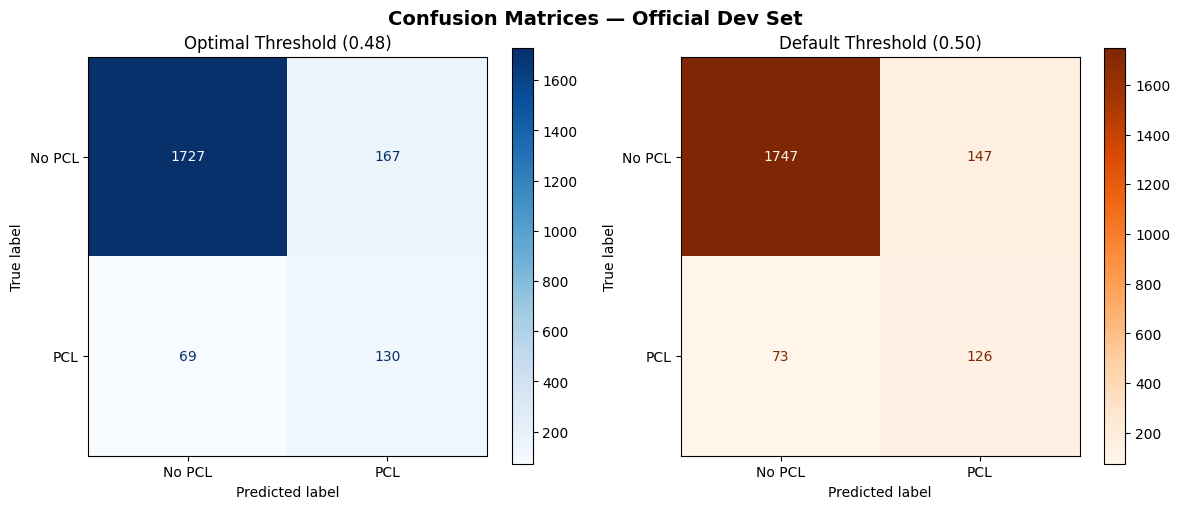


CLASSIFICATION REPORT (Official Dev Set, Optimal Threshold)
              precision    recall  f1-score   support

      No PCL     0.9616    0.9118    0.9360      1894
         PCL     0.4377    0.6533    0.5242       199

    accuracy                         0.8872      2093
   macro avg     0.6996    0.7825    0.7301      2093
weighted avg     0.9118    0.8872    0.8969      2093



In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, average_precision_score, roc_curve, roc_auc_score,
    PrecisionRecallDisplay
)

# --- CONFUSION MATRIX ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Optimal threshold
cm_opt = confusion_matrix(dev_true, dev_preds_optimal)
disp_opt = ConfusionMatrixDisplay(cm_opt, display_labels=["No PCL", "PCL"])
disp_opt.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title(f"Optimal Threshold ({best_thresh:.2f})")

# Default threshold
cm_def = confusion_matrix(dev_true, dev_preds_default)
disp_def = ConfusionMatrixDisplay(cm_def, display_labels=["No PCL", "PCL"])
disp_def.plot(ax=axes[1], cmap="Oranges", values_format="d")
axes[1].set_title("Default Threshold (0.50)")

plt.suptitle("Confusion Matrices — Official Dev Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/confusion_matrix_dev.png", dpi=150, bbox_inches="tight")
plt.show()

# --- CLASSIFICATION REPORT ---
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Official Dev Set, Optimal Threshold)")
print("=" * 60)
print(classification_report(dev_true, dev_preds_optimal, target_names=["No PCL", "PCL"], digits=4))

### Precision-Recall Curve & ROC Curve

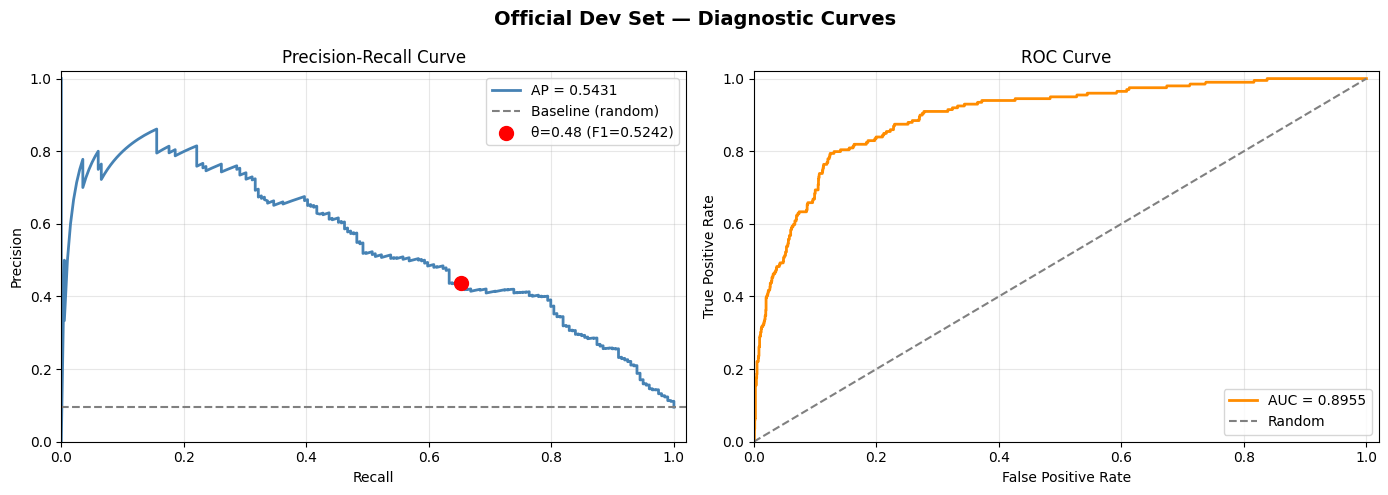

Average Precision (AP): 0.5431
ROC AUC: 0.8955


In [18]:
# --- PRECISION-RECALL & ROC CURVES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(dev_true, dev_probs)
ap_score = average_precision_score(dev_true, dev_probs)

axes[0].plot(recall_curve, precision_curve, color="steelblue", lw=2, label=f"AP = {ap_score:.4f}")
axes[0].axhline(y=sum(dev_true) / len(dev_true), color="gray", linestyle="--", label="Baseline (random)")
# Mark optimal threshold point
opt_p, opt_r = p, r
axes[0].scatter([opt_r], [opt_p], color="red", s=100, zorder=5, label=f"θ={best_thresh:.2f} (F1={f1:.4f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="upper right")
axes[0].set_xlim([0, 1.02])
axes[0].set_ylim([0, 1.02])
axes[0].grid(alpha=0.3)

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(dev_true, dev_probs)
auc_score = roc_auc_score(dev_true, dev_probs)

axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc_score:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].set_xlim([0, 1.02])
axes[1].set_ylim([0, 1.02])
axes[1].grid(alpha=0.3)

plt.suptitle("Official Dev Set — Diagnostic Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/pr_roc_curves_dev.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average Precision (AP): {ap_score:.4f}")
print(f"ROC AUC: {auc_score:.4f}")

### Threshold Sensitivity Analysis
Visualize how F1, Precision, and Recall change across different decision thresholds.

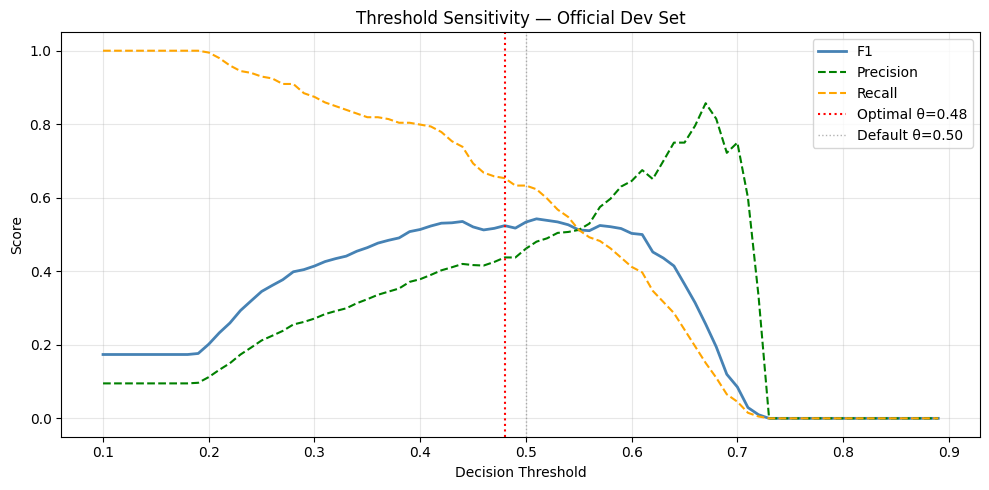

Best dev F1=0.5427 at threshold=0.51
  Precision=0.4806, Recall=0.6231


In [19]:
# --- THRESHOLD SENSITIVITY ---
thresholds = np.arange(0.10, 0.90, 0.01)
f1s, precisions, recalls = [], [], []

for t in thresholds:
    preds_t = (dev_probs >= t).astype(int)
    p_t, r_t, f1_t, _ = precision_recall_fscore_support(
        dev_true, preds_t, average="binary", pos_label=1, zero_division=0
    )
    f1s.append(f1_t)
    precisions.append(p_t)
    recalls.append(r_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s, color="steelblue", lw=2, label="F1")
ax.plot(thresholds, precisions, color="green", lw=1.5, linestyle="--", label="Precision")
ax.plot(thresholds, recalls, color="orange", lw=1.5, linestyle="--", label="Recall")
ax.axvline(x=best_thresh, color="red", linestyle=":", lw=1.5, label=f"Optimal θ={best_thresh:.2f}")
ax.axvline(x=0.5, color="gray", linestyle=":", lw=1, alpha=0.6, label="Default θ=0.50")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity — Official Dev Set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("imgs/threshold_sensitivity_dev.png", dpi=150, bbox_inches="tight")
plt.show()

# Print best F1 and corresponding threshold
best_idx = np.argmax(f1s)
print(f"Best dev F1={f1s[best_idx]:.4f} at threshold={thresholds[best_idx]:.2f}")
print(f"  Precision={precisions[best_idx]:.4f}, Recall={recalls[best_idx]:.4f}")

### Error Analysis
Inspect misclassified samples to understand the model's failure modes: false positives (flagged as PCL but aren't) and false negatives (missed PCL).

In [20]:
# --- ERROR ANALYSIS ---

# Add predictions to dev_df for analysis
dev_df = dev_df.reset_index(drop=True)
dev_df["pred"] = dev_preds_optimal
dev_df["prob"] = dev_probs
dev_df["correct"] = dev_df["pred"] == dev_df["pcl_binary"]

# Categorize errors
tp = dev_df[(dev_df["pcl_binary"] == 1) & (dev_df["pred"] == 1)]
tn = dev_df[(dev_df["pcl_binary"] == 0) & (dev_df["pred"] == 0)]
fp = dev_df[(dev_df["pcl_binary"] == 0) & (dev_df["pred"] == 1)]  # False positives
fn = dev_df[(dev_df["pcl_binary"] == 1) & (dev_df["pred"] == 0)]  # False negatives

print(f"Error Breakdown (Official Dev Set, θ={best_thresh:.2f}):")
print(f"  True Positives:  {len(tp):>5}  (correctly identified PCL)")
print(f"  True Negatives:  {len(tn):>5}  (correctly identified No-PCL)")
print(f"  False Positives: {len(fp):>5}  (flagged as PCL but isn't)")
print(f"  False Negatives: {len(fn):>5}  (missed PCL)")
print(f"  Accuracy: {len(tp) + len(tn)}/{len(dev_df)} = {(len(tp) + len(tn)) / len(dev_df):.4f}")

# --- Most confident errors ---
print("\n" + "=" * 60)
print("TOP 10 FALSE POSITIVES (highest confidence wrong PCL predictions)")
print("=" * 60)
for _, row in fp.nlargest(10, "prob").iterrows():
    text_preview = row["text"][:120] + "..." if len(str(row["text"])) > 120 else row["text"]
    print(f"  [{row['prob']:.3f}] par_id={row['par_id']}: {text_preview}")

print("\n" + "=" * 60)
print("TOP 10 FALSE NEGATIVES (most confident missed PCL)")
print("=" * 60)
for _, row in fn.nsmallest(10, "prob").iterrows():
    text_preview = row["text"][:120] + "..." if len(str(row["text"])) > 120 else row["text"]
    cats = row["label_vec"]
    active_cats = [CATEGORIES[i] for i, v in enumerate(cats) if v > 0]
    print(f"  [{row['prob']:.3f}] par_id={row['par_id']} cats={active_cats}: {text_preview}")

Error Breakdown (Official Dev Set, θ=0.48):
  True Positives:    130  (correctly identified PCL)
  True Negatives:   1727  (correctly identified No-PCL)
  False Positives:   167  (flagged as PCL but isn't)
  False Negatives:    69  (missed PCL)
  Accuracy: 1857/2093 = 0.8872

TOP 10 FALSE POSITIVES (highest confidence wrong PCL predictions)
  [0.730] par_id=9423: christmas is celebration of the birth of not merely a child , but a child who changed the destiny of humans forever . it...
  [0.721] par_id=8978: jesus begins his teaching in matthew with the sermon on the mount . one group he blesses is those in need of comfort , b...
  [0.706] par_id=8838: """ i always consider this job as a gift , being a nurse is a reward and task given by god to help those who are in need...
  [0.693] par_id=10268: """ this new project will see an active engagement with the community to help improve the lives of vulnerable children a...
  [0.691] par_id=9687: "in his condolence message , he said , "" all

### Error Distribution by Keyword
Analyze whether the model struggles more with certain vulnerable-community keywords.

Per-Keyword Performance on Official Dev Set:
----------------------------------------------------------------------
Keyword             N   PCL      F1    Prec     Rec    FP    FN
----------------------------------------------------------------------
disabled          194    14  0.4571  0.3810  0.5714    13     6
homeless          212    29  0.4819  0.3704  0.6897    34     9
hopeless          217    26  0.5000  0.4211  0.6154    22    10
immigrant         218     7  0.5000  0.6000  0.4286     2     4
in-need           226    33  0.6739  0.5254  0.9394    28     2
migrant           206     5  0.5000  0.4286  0.6000     4     2
poor-families     190    38  0.5116  0.4583  0.5789    26    16
refugee           188    13  0.3125  0.2632  0.3846    14     8
vulnerable        209    20  0.6154  0.5000  0.8000    16     4
women             233    14  0.4286  0.4286  0.4286     8     8


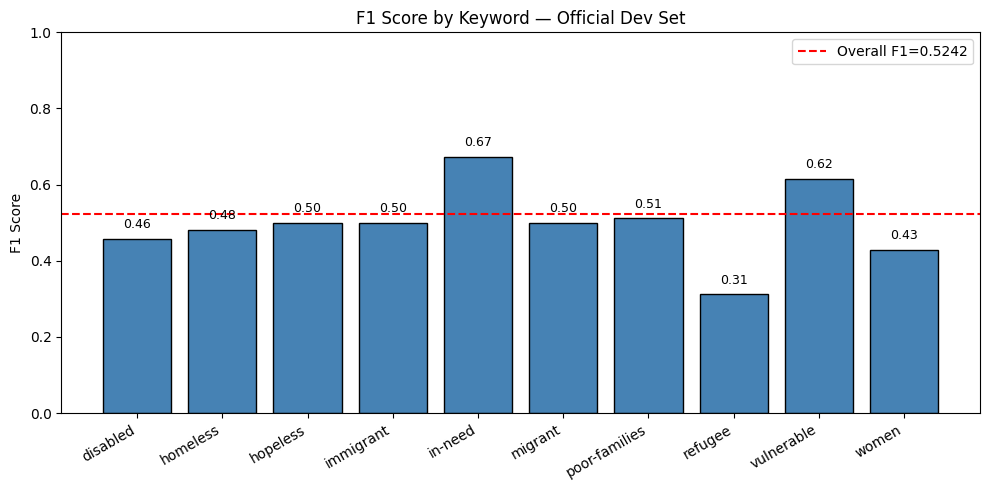

In [21]:
# --- ERROR ANALYSIS BY KEYWORD ---

# Map par_ids to keywords from the main dataset
keyword_lookup = df.set_index("par_id")["keyword"].to_dict()
dev_df["keyword"] = dev_df["par_id"].map(keyword_lookup)

# Per-keyword metrics
print("Per-Keyword Performance on Official Dev Set:")
print("-" * 70)
print(f"{'Keyword':<15} {'N':>5} {'PCL':>5} {'F1':>7} {'Prec':>7} {'Rec':>7} {'FP':>5} {'FN':>5}")
print("-" * 70)

keyword_stats = []
for kw in sorted(dev_df["keyword"].dropna().unique()):
    mask = dev_df["keyword"] == kw
    kw_true = dev_df.loc[mask, "pcl_binary"].values
    kw_pred = dev_df.loc[mask, "pred"].values
    n_pcl = kw_true.sum()

    if len(kw_true) == 0:
        continue

    p_kw, r_kw, f1_kw, _ = precision_recall_fscore_support(
        kw_true, kw_pred, average="binary", pos_label=1, zero_division=0
    )
    n_fp = ((kw_pred == 1) & (kw_true == 0)).sum()
    n_fn = ((kw_pred == 0) & (kw_true == 1)).sum()
    print(f"{kw:<15} {len(kw_true):>5} {n_pcl:>5} {f1_kw:>7.4f} {p_kw:>7.4f} {r_kw:>7.4f} {n_fp:>5} {n_fn:>5}")
    keyword_stats.append({"keyword": kw, "n": len(kw_true), "pcl": n_pcl, "f1": f1_kw, "fp": n_fp, "fn": n_fn})

# Visualize
kw_stats_df = pd.DataFrame(keyword_stats)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(kw_stats_df["keyword"], kw_stats_df["f1"], color="steelblue", edgecolor="black")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Keyword — Official Dev Set")
ax.set_ylim([0, 1.0])
ax.axhline(y=f1, color="red", linestyle="--", lw=1.5, label=f"Overall F1={f1:.4f}")
ax.legend()
for bar, row in zip(bars, kw_stats_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{row.f1:.2f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("imgs/f1_by_keyword_dev.png", dpi=150, bbox_inches="tight")
plt.show()

### Prediction Confidence Distribution
Visualize the model's confidence for correct vs. incorrect predictions.

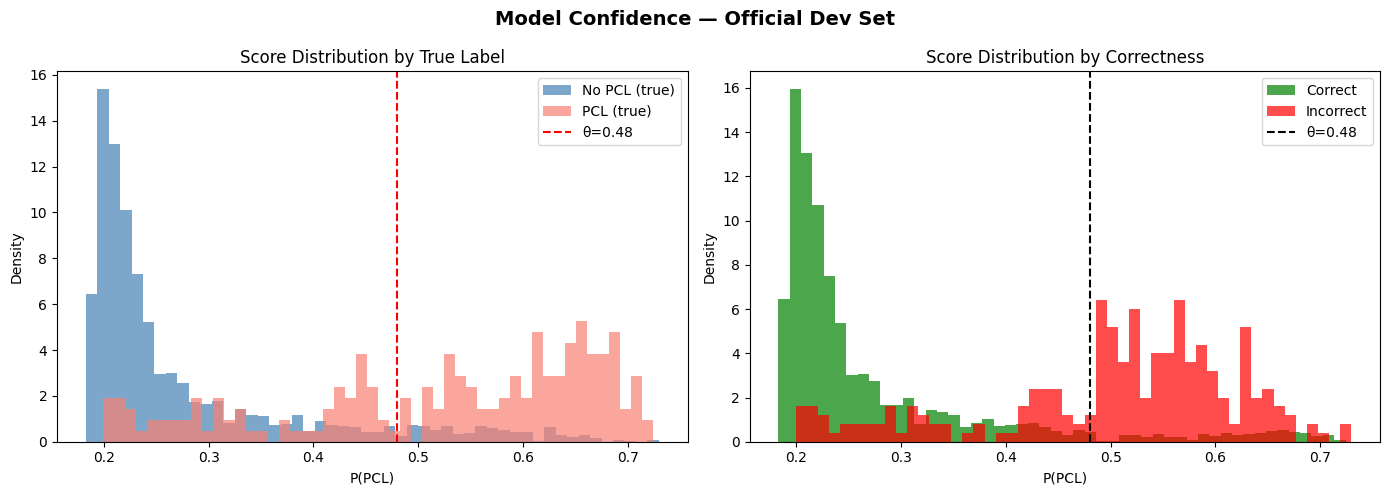

In [22]:
# --- CONFIDENCE DISTRIBUTION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By true label
axes[0].hist(dev_probs[dev_true == 0], bins=50, alpha=0.7, color="steelblue", label="No PCL (true)", density=True)
axes[0].hist(dev_probs[dev_true == 1], bins=50, alpha=0.7, color="salmon", label="PCL (true)", density=True)
axes[0].axvline(x=best_thresh, color="red", linestyle="--", lw=1.5, label=f"θ={best_thresh:.2f}")
axes[0].set_xlabel("P(PCL)")
axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution by True Label")
axes[0].legend()

# By correctness
correct_mask = dev_df["correct"].values
axes[1].hist(dev_probs[correct_mask], bins=50, alpha=0.7, color="green", label="Correct", density=True)
axes[1].hist(dev_probs[~correct_mask], bins=50, alpha=0.7, color="red", label="Incorrect", density=True)
axes[1].axvline(x=best_thresh, color="black", linestyle="--", lw=1.5, label=f"θ={best_thresh:.2f}")
axes[1].set_xlabel("P(PCL)")
axes[1].set_ylabel("Density")
axes[1].set_title("Score Distribution by Correctness")
axes[1].legend()

plt.suptitle("Model Confidence — Official Dev Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/confidence_distribution_dev.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary of Results

In [23]:
# --- FINAL SUMMARY ---
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n{'Metric':<30} {'Val Set':>10} {'Dev Set':>10}")
print("-" * 52)

# Val set metrics (from threshold optimization)
val_p, val_r, val_f1, _ = precision_recall_fscore_support(
    preds_output.label_ids,
    (torch.softmax(torch.tensor(preds_output.predictions), dim=-1)[:, 1].numpy() >= best_thresh).astype(int),
    average="binary", pos_label=1, zero_division=0
)
print(f"{'F1 Score':<30} {val_f1:>10.4f} {f1:>10.4f}")
print(f"{'Precision':<30} {val_p:>10.4f} {p:>10.4f}")
print(f"{'Recall':<30} {val_r:>10.4f} {r:>10.4f}")
print(f"{'Accuracy':<30} {accuracy_score(preds_output.label_ids, (torch.softmax(torch.tensor(preds_output.predictions), dim=-1)[:, 1].numpy() >= best_thresh).astype(int)):>10.4f} {acc:>10.4f}")
print(f"{'ROC AUC':<30} {'—':>10} {auc_score:>10.4f}")
print(f"{'Average Precision':<30} {'—':>10} {ap_score:>10.4f}")

print(f"\n{'Configuration':<30} {'Value':>10}")
print("-" * 42)
print(f"{'Model':<30} {'ALBERT-large-v2':>10}")
print(f"{'Optimal Threshold':<30} {best_thresh:>10.2f}")
print(f"{'Effective Batch Size':<30} {BATCH_SIZE * GRAD_ACCUMULATION:>10}")
print(f"{'Learning Rate':<30} {LR:>10.2e}")

print(f"\n{'Submission Files':<30}")
print("-" * 42)
print(f"  dev.txt  — {len(dev_preds_optimal)} predictions")
print(f"  test.txt — {len(test_preds)} predictions")
print(f"  Model saved to ./pcl_multitask_model/")

FINAL RESULTS SUMMARY

Metric                            Val Set    Dev Set
----------------------------------------------------
F1 Score                           0.5532     0.5242
Precision                          0.4771     0.4377
Recall                             0.6582     0.6533
Accuracy                           0.8998     0.8872
ROC AUC                                 —     0.8955
Average Precision                       —     0.5431

Configuration                       Value
------------------------------------------
Model                          ALBERT-large-v2
Optimal Threshold                    0.48
Effective Batch Size                   32
Learning Rate                    4.22e-05

Submission Files              
------------------------------------------
  dev.txt  — 2093 predictions
  test.txt — 3832 predictions
  Model saved to ./pcl_multitask_model/
